## OBJETIVO 3: Analizar la exigencia y los aspectos relevantes según la nacionalidad de cada usuario (definir pocas nacionalidades)

## 0. Librerías y cargar datos

In [1]:
# Librerías
import pandas as pd
import numpy as np
# NLP clásico
import spacy
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
# Topic modeling
from sentence_transformers import SentenceTransformer # embeddings
from bertopic import BERTopic # topic modeling
from umap import UMAP # reducción de dimensionalidad
from hdbscan import HDBSCAN # clusterización
# Visualización
import seaborn as sns
import matplotlib.pyplot as plt
# Análisis de especifidad
from scipy.stats import chi2_contingency

Para esta fase del proyecto identificamos y filtramos el dataset del conjunto completo de reseñas para quedarnos únicamente con las diez nacionalidades que acumulan el mayor volumen de reseñas, garantizando así la solidez estadística del estudio. Hemos desarrollado un algoritmo de limpieza que aplicamos de forma independiente a los comentarios positivos y negativos. Con esta función eliminamos respuestas evasivas tipo "nada" y lematizamos cada palabra para reducirla a su raíz semántica, obteniendo así un corpus completamente normalizado y listo para la extracción de conclusiones.

In [2]:
# Cargamos los datos completos
df_base = pd.read_csv('datos/procesados/df_comentarios_traducidos.csv')

# Detectamos automáticamente las 10 nacionalidades con más reseñas
nacionales_top = df_base['nacionalidad'].value_counts().head(10).index.tolist()
print(f"Nacionalidades principales detectadas para el estudio: {nacionales_top}")

# Creamos el DataFrame de trabajo filtrado
df_proyecto = df_base[df_base['nacionalidad'].isin(nacionales_top)].copy()

# Cargar spaCy en español
nlp = spacy.load('es_core_news_sm')
stopwords_es = list(nlp.Defaults.stop_words)

# Rescatamos palabras clave que indican queja o cuantificación
relevantes = ['mejor', 'buenas', 'no', 'más', 'buenos', 'pocos', 'apenas', 'tampoco', 'buena', 'bastante']
for palabra in relevantes:
    if palabra in stopwords_es:
        stopwords_es.remove(palabra)

# Añadimos palabras obvias que sesgan el análisis de hoteles
stopwords_es.extend(["hotel", "valencia", "habitacion", "habitación", "alojamiento", "estancia", "establecimiento"])

def limpiar_y_lematizar(texto):
    """Transforma el texto a minúsculas, elimina stopwords y extrae la raíz (lema)"""
    if pd.isna(texto) or str(texto).strip() == "" or str(texto).lower() == "ninguna" or str(texto).lower() == "nada":
        return ""
    
    doc = nlp(str(texto).lower())
    # Filtramos por longitud y stopwords, extrayendo el lema
    tokens_limpios = [token.lemma_ for token in doc if token.text not in stopwords_es and len(token.text) >= 3]
    return ' '.join(tokens_limpios)

print("Limpiando textos de reseñas... Esto puede tardar un par de minutos.")
# Aplicamos la limpieza de forma independiente a la columna de positivos y de negativos
df_proyecto['positivo_clean'] = df_proyecto['positivo'].apply(limpiar_y_lematizar)
df_proyecto['negativo_clean'] = df_proyecto['negativo'].apply(limpiar_y_lematizar)
print("¡Textos listos y normalizados!")

# Guardamos los textos procesados, posteriormente podemos cargar este dataframe en lugar de volver a lematizar
df_proyecto.to_csv("datos/procesados/df_lemas_10_nacionalidades.csv", index=False, encoding='utf-8-sig')

# Mostramos cómo ha quedado el dataframe
display(df_proyecto.head())

Nacionalidades principales detectadas para el estudio: ['españa', 'italia', 'reino unido', 'países bajos', 'alemania', 'francia', 'suiza', 'bélgica', 'argentina', 'estados unidos']
Limpiando textos de reseñas... Esto puede tardar un par de minutos.
¡Textos listos y normalizados!


,nombre_del_hotel,nacionalidad,detalles_hab,noches,personas,comentario_general,positivo,negativo,nota,fecha,comentario_media_hotel,positivo_clean,negativo_clean
1,barceló valencia,españa,NaN,1,pareja,muy bien,NaN,NaN,9.0,2026-04-05,fabuloso,,
2,barceló valencia,españa,2 habitaciones dobles deluxe comunicadas,1,familia,fantástico,"habitaciones amplias, limpieza y ubicación",NaN,9.0,2026-04-03,fabuloso,habitación amplio limpieza ubicación,
3,barceló valencia,españa,NaN,1,pareja,todo perfecto,el trato en recepción,el estacionamiento,10.0,2026-03-21,fabuloso,trato recepción,estacionamiento
4,barceló valencia,españa,NaN,2,pareja,una nit del foc inolvidable.,las vistas y el tamaño de la habitación.,"la calefacción central, sólo eso.",10.0,2026-03-20,fabuloso,vista tamaño,calefacción central
5,barceló valencia,españa,NaN,1,pareja,excepcional,me encantó,todo súper bien,10.0,2026-03-17,fabuloso,encantar,súper


## 1. Primera prueba: una única nacionalidad
Para realizar las primeras pruebas sobre el proceso de extracción de topics y análisis por nacionalidad nos centraremos en un subconjunto más pequeño de los datos restringiéndolos a una nacionalidad concreta. 
Hemos escogido realizar esta prueba con los comentarios de clientes procedentes de bélgica, ha resultado interesante realizar esta prueba para un país no hispanohablante para verificar si el reducido número de reseñas que quedaron sin traducir (la traducción automática no funcionó correctamente) suponen un problema o si utilizar un modelo multilingue permite procesar sin problemas estos datos en el conjunto.

In [3]:
# De momento probamos con una nacionalidad, bélgica
df = df_proyecto[df_proyecto['nacionalidad']=='bélgica']

display(df.head())

,nombre_del_hotel,nacionalidad,detalles_hab,noches,personas,comentario_general,positivo,negativo,nota,fecha,comentario_media_hotel,positivo_clean,negativo_clean
431,barceló valencia,bélgica,NaN,1,persona que viaja sola,hotel superior,desayuno y bar en la azotea,la condición física podría ser mejor,9.0,2025-06-02,fabuloso,desayuno bar azotea,condición físico mejor
456,barceló valencia,bélgica,NaN,4,pareja,estancia perfecta! ¡Esperando con ansias mi pr...,hermoso hotel; Mejor ubicación entre el centro...,NaN,9.0,2025-01-02,fabuloso,hermoso mejor ubicación centro histórico playa...,
584,barceló valencia,bélgica,NaN,1,pareja,Un lugar genial para alojarse en Valencia.,"excelente personal, excelente ubicación, marav...",NaN,9.0,2023-06-05,fabuloso,excelente personal excelente ubicación maravil...,
586,barceló valencia,bélgica,NaN,4,grupo,"gran servicio, excelente ubicación, excelente ...","Super desayuno, personal servicial y muy acoge...",no hay nada que no me haya gustado. fue perfecto,10.0,2023-05-30,fabuloso,super desayuno personal servicial acogedor her...,gustar perfecto
643,barceló valencia,bélgica,NaN,3,persona que viaja sola,el hotel estaba bien,desayuno perfecta ubicación ok,El café y el agua en la habitación solo a la l...,9.0,2023-05-16,fabuloso,desayuno perfecto ubicación,café agua llegada volver llenar café


### 1.1 Extracción de embeddings y topic modeling
En primer lugar extraeremos los embeddings de cada reseña, utilizando un SentenceTransformer para que se tenga en cuenta el contexto de oraciones completas, en lugar de solamente cada palabra por separado.  
Estos embeddings se extraen con el texto "en sucio" de nuestro dataset: traducido, sin emojis y en minúsculas, pero sin lematización ni eliminación de stopwords.  
Posteriormente utilizaremos BERTopic para extraer los temas, la clusterización se realizará con los embeddings calculados pero para posteriormente asignar sentido a cada tema con TF-IDF haremos una limpieza previa de las stopwords definidas anteriormente.

In [4]:
# Para topic modeling nos quedaremos con los comentarios sin lematizar, generalmente mejores para modelos transformer
# Extraer positivos y negativos con su etiqueta
pos = df[['positivo']].dropna().rename(columns={'positivo': 'text'})
pos['sentiment'] = 'Positivo'

neg = df[['negativo']].dropna().rename(columns={'negativo': 'text'})
neg['sentiment'] = 'Negativo'

# Combinar ambos en un solo corpus
df_mixed = pd.concat([pos, neg], ignore_index=True)
documents = df_mixed['text'].astype(str).tolist()

print(f"Total de documentos (Pos + Neg) bélgica: {len(pos)}+{len(neg)} = {len(documents)}")


# Extracción de embeddings
#embedding_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
embedding_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-mpnet-base-v2")
embeddings = embedding_model.encode(documents, show_progress_bar=True)

# Reducción de dimensionalidad y Clustering
umap_model = UMAP(n_neighbors=15, n_components=3, min_dist=0.0, metric='cosine', random_state=42)

hdbscan_model = HDBSCAN(min_cluster_size=20, min_samples=10, metric='euclidean', cluster_selection_method='eom', prediction_data=True)

# Vectorizador
# Código para obtener las stopwords por si se tiene que volver a ejecutar

# # Cargar spaCy en español
# nlp = spacy.load('es_core_news_sm')
# stopwords_es = list(nlp.Defaults.stop_words)
# # Rescatamos palabras clave que indican queja o cuantificación
# relevantes = ['mejor', 'buenas', 'no', 'más', 'buenos', 'pocos', 'apenas', 'tampoco', 'buena', 'bastante']
# for palabra in relevantes:
#     if palabra in stopwords_es:
#         stopwords_es.remove(palabra)
# # Añadimos palabras obvias que sesgan el análisis de hoteles
# stopwords_es.extend(["hotel", "valencia", "habitacion", "habitación", "alojamiento", "estancia", "establecimiento"])

#Configuramos el vectorizador
# El token_pattern r"(?u)\b[a-zA-ZáéíóúÁÉÍÓÚñÑ]{2,}\b" obliga a que los tokens:
# - Tengan al menos 2 caracteres.
# - Solo contengan letras (incluyendo tildes y ñ), eliminando así los números.
vectorizer_model = CountVectorizer(
    stop_words=stopwords_es, #ademas de quitar las stopwords
    token_pattern=r"(?u)\b[a-zA-ZáéíóúÁÉÍÓÚñÑ]{2,}\b"
)

# Al crear el modelo, le pasamos este vectorizador
topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    language="multilingual"
)

# Aquí puedes usar los documents originales sin problemas
topics, probs = topic_model.fit_transform(documents, embeddings)
df_mixed["topic"] = topics

Total de documentos (Pos + Neg) bélgica: 746+617 = 1363


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/43 [00:00<?, ?it/s]

A continuación analizaremos los temas obtenidos y las opiniones de los huéspedes respecto a cada uno de ellos en base a las reseñas positivas y negativas de cada uno de ellos.

In [5]:
# Ver la distribución de sentimiento por cada tema encontrado
df_distribucion = df_mixed.groupby(['topic', 'sentiment']).size().unstack(fill_value=0)
df_distribucion['Total'] = df_distribucion.sum(axis=1)
df_distribucion['% Positivo'] = (df_distribucion['Positivo'] / df_distribucion['Total'] * 100).round(2)

print("Distribución de sentimiento por Topic (¿Hubo separación?):")
display(df_distribucion)

# Mostrar palabras clave de los temas con más "Negativos" y más "Positivos"
topic_info = topic_model.get_topic_info()
display(topic_info.head(10))

Distribución de sentimiento por Topic (¿Hubo separación?):


sentiment,Negativo,Positivo,Total,% Positivo
topic,,,,
-1,33,2,35,5.71
0,455,658,1113,59.12
1,45,19,64,29.69
2,28,24,52,46.15
3,1,41,42,97.62
4,29,1,30,3.33
5,26,1,27,3.70


,Topic,Count,Name,Representation,Representative_Docs
0,-1,35,-1_especial_absolutamente_mencionar_destacar,"[especial, absolutamente, mencionar, destacar,...","[nada especial que mencionar, nada especial, n..."
1,0,1113,0_no_desayuno_ubicación_personal,"[no, desayuno, ubicación, personal, amable, ex...",[excelente desayuno personal amable excelente ...
2,1,64,1_situación_pulgar_azotea_actividad,"[situación, pulgar, azotea, actividad, emplaza...","[la situación, Las actividades podrían ser mej..."
3,2,52,2_perfecto_agrado_quejarse_negativo,"[perfecto, agrado, quejarse, negativo, reporta...","[Todo estuvo perfecto!, perfecto, todo fue per..."
4,3,42,3_ubicación_locatie_privilegiada_rutas,"[ubicación, locatie, privilegiada, rutas, únic...","[ubicación, ubicación, ubicación]"
5,4,30,4_realidad_realmente__,"[realidad, realmente, , , , , , , , ]","[nada, realmente nada!, en realidad nada]"
6,5,27,5_comentarios_aplicable_inmediato_no,"[comentarios, aplicable, inmediato, no, pensar...","[sin comentarios, sin comentarios., sin coment..."


Analizamos también algunos ejemplos de reseñas para cada topic:

In [6]:
for topic in np.unique(topics):
    if topic == -1:
        continue

    print(f'======= TOPIC  {topic} =======')
    # Mostramos palabras clave
    words = topic_model.get_topic(topic)
    topic_words = [word for word, score in words[:5]]
    print('Palabras clave: ', ' '.join(topic_words))

    # Mostramos tres ejemplos de comentarios positivos y negativos (si hay)
    # Positivos
    if df_distribucion['Positivo'][topic] >= 3:
        print('\n Comentarios positivos')
        aux = df_mixed[df_mixed['sentiment']=='Positivo'][df_mixed['topic']==topic].sample(3)
        aux = aux['text'].tolist()
        print('\n'.join(aux))

    elif df_distribucion['Positivo'][topic] > 0:
        print('\n Comentarios positivos')
        aux = df_mixed[df_mixed['sentiment']=='Positivo'][df_mixed['topic']==topic]

    # Negativos 
    if df_distribucion['Negativo'][topic] >= 3:
        print('\n Comentarios negativos')
        aux = df_mixed[df_mixed['sentiment']=='Negativo'][df_mixed['topic']==topic].sample(3)
        aux = aux['text'].tolist()
        print('\n'.join(aux))

    elif df_distribucion['Negativo'][topic] > 0:
        print('\n Comentarios negativos')
        aux = df_mixed[df_mixed['sentiment']=='Negativo'][df_mixed['topic']==topic]
        aux = aux['text'].tolist()
        print('\n'.join(aux))


======= TOPIC  0 =======
Palabras clave:  no desayuno ubicación personal amable

 Comentarios positivos
Tuve que cambiarme en el último momento del Hotel Las Arenas al Hotel Nautic. pero el hotel nautic fue muy agradable y ciertamente cumplió con las expectativas. El desayuno y la cena fueron muy sabrosos y muy completos. el personal fue amable. la habitación era cómoda y muy limpia. fue una estancia agradable.
la ubicación el desayuno
la ubicación era fantástica

 Comentarios negativos
durante el estacionamiento
más panecillos integrales y quizás jugo de naranja fresco en la tierra de las naranjas
No conseguí la habitación que reservamos el domingo, llamaron varias veces por el ruido.
======= TOPIC  1 =======
Palabras clave:  situación pulgar azotea actividad emplazamiento

 Comentarios positivos
recepción,
la situación!
súper

 Comentarios negativos
-
¡Me picaron las chinches!
nada
======= TOPIC  2 =======
Palabras clave:  perfecto agrado quejarse negativo reportar

 Comentarios posi

Los resultados para este método parecen ser difíciles de interpretar y no dan lugar a conclusiones claras.

### 1.2. Análisis clásico
Ya que el topic modeling probado no ha llevado a resultados muy concluyentes a continuación realizaremos un análisis clásico de las reseñas basado en frecuencias de palabras, concretamente utilizaremos las técnicas TF-IDF y Log Odds Ratio. Para este tipo de aplicaciones sí que es conveniente utilizar el texto limpio, sin stopwords y con lematización.

#### 1.2.1 TF-IDF
Utilizaremos TF-IDF para extraer los términos más relevantes para cada nacionalidad, con el objetivo de posteriormente realizar un estudio comparativo entre ellos (DELTA TF-IDF). 

In [7]:
# Obtenemos los documentos a partir de las reseñas limpias
# Extraer positivos y negativos con su etiqueta
pos = df[['positivo_clean']].dropna().rename(columns={'positivo_clean': 'text'})
pos['sentiment'] = 'Positivo'
# Eliminar celdas vacías
pos = pos[pos['text'] != ""]

neg = df[['negativo_clean']].dropna().rename(columns={'negativo_clean': 'text'})
neg['sentiment'] = 'Negativo'
# Eliminar celdas vacías
neg = neg[neg['text'] != ""]

# Combinar ambos en un solo corpus
df_mixed = pd.concat([pos, neg], axis=0, ignore_index=True)
lemma_docs = df_mixed['text'].astype(str).tolist()

In [8]:
# Apicamos TF-IDF y obtenemos palabras de mayor peso
tv = TfidfVectorizer(ngram_range=(2,2), min_df=0.003, max_df=0.6, norm=None) # Palabras únicas son difíciles de interpretar, nos centramos en bigramas y trigramas
# Hacemos fit de tv a los comentarios tanto positivos como negativos
tv_sparse_matrix = tv.fit_transform(lemma_docs)

tv_matrix = tv_sparse_matrix.toarray()
vocab_bigram = tv.get_feature_names_out()

# Obtenemos los 40 elementos de mayor peso (más adelante evaluaremos cuántos conviene utilizar para comparar)
idx_top = np.argsort(tv_matrix.max(axis=0))[-40:]
palabras_top = vocab_bigram[idx_top]
print(palabras_top)

['máquina café' 'minuto pie' 'metro estación' 'escobilla baño'
 'lugar interés' 'escuchar ruido' 'oir ruido' 'limpio moderno'
 'espera ascensor' 'extremadamente amable' 'fácilmente accesible'
 'lejos centro' 'haber reservar' 'in check' 'ideal centro' 'espaciós cama'
 'definitivamente recomendado' 'parada autobús' 'pequeño baño'
 'desayuno caro' 'desayuno limpio' 'punto negativo' 'desayuno pequeño'
 'desayuno perfecto' 'plaza ayuntamiento' 'piscina abierto'
 'patio interior' 'personal super' 'personal extremadamente'
 'personal excelente' 'desayuno súper' 'dormir noche' 'perfecto desayuno'
 'pequeño ventana' 'desayuno sencillo' 'abrir ventana'
 'aire acondicionado' 'habitación pequeño' 'tener esperar' 'bonito bar']


A continuación trataremos de estimar cómo se sienten los clientes acerca de cada uno de los términos de gran importancia nombrados evaluando la proporción de apariciones que tienen estas palabras en reseñas positivas vs negativas.

In [9]:
# Obtener proporción de cada término en reseñas positivas/negativas
# Utilizamos un dataframe auxiliar para reco
df_tv = pd.DataFrame(np.round(tv_matrix, 2), columns=vocab_bigram)

# Creamos variable de dataframe para la proporción de cada término
df_prop_tv = None

# Recorremos cada término
for ngrama in palabras_top:
    # Encontrar el índice de los documentos en los que su score no es 0, usarlo en df_mixed para hallar el tipo de reseña
    sentimientos = df_mixed['sentiment'][df_tv[ngrama]!=0.0].to_numpy()
    # Proporción positivos
    prop_pos = np.sum(sentimientos=='Positivo')/len(sentimientos)
    # Proporción negativos
    prop_neg = np.sum(sentimientos=='Negativo')/len(sentimientos)
    # Si el dataframe no existe lo creamos, si ya existe se inserta una nueva fila
    if isinstance(df_prop_tv, pd.DataFrame): 
        df_prop_tv.loc[len(df_prop_tv)] = [ngrama, prop_pos, prop_neg]
    else:
        df_prop_tv = {'Término': [ngrama], 'Proporcion positivo': [prop_pos], 'Proporcion negativo': [prop_neg]}
        df_prop_tv = pd.DataFrame(df_prop_tv)
    
# Vemos cómo quedaría en los 10 primeros casos
display(df_prop_tv.head(20))

,Término,Proporcion positivo,Proporcion negativo
0,máquina café,0.00,1.00
1,minuto pie,1.00,0.00
2,metro estación,1.00,0.00
3,escobilla baño,0.00,1.00
4,lugar interés,1.00,0.00
5,escuchar ruido,0.25,0.75
6,oir ruido,0.25,0.75
7,limpio moderno,1.00,0.00
8,espera ascensor,0.00,1.00
9,extremadamente amable,1.00,0.00


#### 1.2.2 Log Odds Ratio with Informative Dirichlet Prior
A la hora de analizar frecuencias de palabras en documentos, una alternativa a los métodos TF-IDF o Bag of Words es el Log Odds Ratio, esta métrica tratará de evaluar la probabilidad de encontrar una palabra o n-grama en una determinada categoría (en nuestro caso, una nacionalidad) respecto a la probabilidad de que esta palabra se encuentre en otra categoría.   
Dado que este es un método directamente comparativo no podemos hacer esta primera prueba solamente con los datos de una nacionalidad, por lo que escogeremos una segunda nacionalidad con la que comparar (más adelante ya se realizará para todas las nacionalidades).  

In [10]:
# Compararemos con, por ejemplo, las reseñas de Italia
df2 = df_proyecto[df_proyecto['nacionalidad'] == 'italia']

# Extraer positivos y negativos con su etiqueta
pos2 = df2[['positivo_clean']].dropna().rename(columns={'positivo_clean': 'text'})
pos2['sentiment'] = 'Positivo'
# Eliminar celdas vacías
pos2 = pos2[pos2['text'] != ""]

neg2 = df2[['negativo_clean']].dropna().rename(columns={'negativo_clean': 'text'})
neg2['sentiment'] = 'Negativo'
# Eliminar celdas vacías
neg2 = neg2[neg2['text'] != ""]

# Obtenemos un dataframe combinado para consultas posteriores
df_mixed_it = pd.concat([pos2, neg2], ignore_index=True)

print(f"Total de documentos (Pos + Neg) italia: {len(pos2)}+{len(neg2)} = {len(df_mixed_it)}")

Total de documentos (Pos + Neg) italia: 4852+2847 = 7699


Para calcular el z-score de log odds partimos de las cuentas de cada palabra en cada documento, y en total, para realizar esta parte de manera rápida y automática utilizaremos Bag of Words de spacy. Como lo que queremos saber es la frecuencia de las palabras para cada nacionalidad necesitaremos tener un corpus completo común, uniremos los dos corpus normalizados que tenemos creando también una nueva variable (etiquetas) que permita consultar posteriormente a qué nacionalidad pertenece cada documento. Definimos a continuación una función para realizar este proceso.

In [11]:
def contar_palabras_nacionalidad(docs, etiquetas, ngram_range=(1,2)):
    # Bag of words del corpus completo
    cv = CountVectorizer(ngram_range=ngram_range, min_df=0.003, max_df=0.6)
    cv_matrix_sparse = cv.fit_transform(docs)
    cv_matrix = cv_matrix_sparse.toarray()
    # Vocabulario
    vocab = cv.get_feature_names_out()
    # Guardamos las cuentas en un dataframe para tener referencia de a qué término pertenece cada uno
    df_bow = pd.DataFrame(cv_matrix, columns=vocab)

    # Ahora creamos otro dataframe que permita obtener las cuentas de cada término por nacionalidad (agrupando)
    # Tendremos que iterar por las etiquetas
    cuentas_nac = []
    for etiqueta in np.unique(etiquetas):
        cuentas_nac.append(df_bow.loc[np.array(etiquetas)==etiqueta,:].sum(axis=0))
    
    # dataframe completo
    df_counts = pd.concat(cuentas_nac, axis=1).transpose()
    # crear diccionario para renombrar indices
    rename_idx = {i: nacionalidad for i, nacionalidad in enumerate(np.unique(etiquetas))}
    df_counts = df_counts.rename(index=rename_idx)

    return df_counts

Una vez tenemos las apariciones de cada n-grama divididas por nacionalidad trataremos de implementar el cálculo del score correspondiente a Log Odds Ratio. Este score se calcularía así:  
$$ \log{\frac{p_1}{(1-p_1)}}=\log{\frac{p_1}{p_2}} = \log{p_1} - \log{p_2} $$

donde $p_1$ es la probabilidad de que un cierto n-grama aparezca en el corpus 1 y $p_2$ la probabilidad de que aparezca en el corpus 2. Si se trabaja con cuentas de cada palabra, $c_1$ para las apariciones en el corpus 1 y $c_2$ para sus apariciones en el corpus 2 (donde $\Sigma c_1$ y $\Sigma c_2$ son el número total de n-gramas que aparecen en cada corpus) el término se reescribe como:

$$ \log{\frac{c_1}{\Sigma c_1}} - \log{\frac{c_2}{\Sigma c_2}} = \log{c_1} - \log{\Sigma c_1} - \log{c_2} + \log{\Sigma c_2} $$

Adicionalmente, con tal de evitar posibles errores cuando alguno de estos términos ($c_1$ o $c_2$) es 0 y suavizar la función se añade tanto a $c_1$ como a $c_2$ una pequeña cantidad determinada por un parámetro $\alpha$.

In [12]:
def LogOdds_2nac(df_counts, alpha=0.01): # Función adaptada a tener solamente 2 nacionalidades diferentes
    # Nacionalidades
    nac1, nac2 = df_counts.index.tolist()

    # Cuentas totales
    c1_total = df_counts.loc[nac1,:].sum()
    c2_total = df_counts.loc[nac2,:].sum()
    # Dataframe para guardar los resultados
    logodds = pd.DataFrame(data=np.zeros((1, df_counts.shape[1])), columns=df_counts.columns, index=[0])

    # Iteramos sobre cada término
    for col in df_counts.columns.tolist():
        # Cuentas
        c1 = df_counts.loc[nac1, col]
        c2 = df_counts.loc[nac2, col]

        # Suavizado
        c1 += alpha
        c2 += alpha

        # Calcular score
        zscore = np.log(c1) - np.log(c1_total) - np.log(c2) + np.log(c2_total)

        # Guardar score en logodds
        logodds.loc[0,col] = zscore

    # Guardamos logodds ordenado
    logodds = logodds.sort_values(by=0, axis=1)

    return logodds

Para este estudio resulta interesante mantener la información de si los términos utilizados más por una nacionalidad u otra vienen referidos a quejas o comentarios positivos, por lo que realizaremos el cálculo de las puntuaciones de forma separada para los comentarios positivos y negativos.

**Comentarios positivos:**

In [13]:
# Corpus completo
pos_total = pd.concat([pos['text'], pos2['text']]).tolist()
# Etiquetas nacionalidad, de aquí sacaremos los índices para filtrar posteriormente
nac_docs_pos = np.array(['bélgica']*len(pos) + ['italia']*len(pos2))

# Contar apariciones de cada palabras
cuentas_pos = contar_palabras_nacionalidad(pos_total, nac_docs_pos)
display(cuentas_pos)
# Calcular logodds, términos muy negativos son más frecuentes para italia y positicos para bélgica
logodds_pos = LogOdds_2nac(cuentas_pos)
display(logodds_pos)

,abierto,absolutamente,abundante,abundante desayuno,abundante variado,accesible,acceso,acogedor,acogedor limpio,acogedor servicial,...,zona,zona común,zona tranquilo,área,él,él ciudad,él pie,óptimo,único,útil
bélgica,1,4,16,2,2,6,7,10,0,0,...,14,2,0,1,17,0,1,1,3,2
italia,22,33,198,43,27,40,26,217,19,24,...,193,30,22,26,184,30,22,30,39,41


,estructura,posición,dulce,estratégico,salado,italiano,dulce salado,comunicado,oceanográfico,excelente limpieza,...,genial,ubicación ideal,delicioso,azotea,ropa cama,buena,antiguo,casco,casco antiguo,buena cama
0,-8.425949,-7.975992,-7.40434,-7.336751,-7.161412,-6.979107,-6.873757,-6.816606,-6.691458,-6.691458,...,2.25602,2.331367,2.377865,2.489029,2.518738,2.661847,2.720678,2.818676,2.923926,4.367


In [14]:
# Sacamos los 10 términos más característicos de cada nacionalidad
top_10_it = logodds_pos.iloc[:,0:10].columns.tolist() # Los scores más negativos
top_10_bel = logodds_pos.iloc[:,-11:-1].columns.tolist() # Los scores más positivos

print(f'''Términos utilizados más característicos de cada nacionalidad en reseñas positivas: \n Bélgica: {" ".join(top_10_bel)} \n Italia: {" ".join(top_10_it)}''')

Términos utilizados más característicos de cada nacionalidad en reseñas positivas: 
 Bélgica: ubicación genial genial ubicación ideal delicioso azotea ropa cama buena antiguo casco casco antiguo 
 Italia: estructura posición dulce estratégico salado italiano dulce salado comunicado oceanográfico excelente limpieza


**Comentarios negativos:**

In [15]:
# Corpus completo
neg_total = pd.concat([neg['text'], neg2['text']]).tolist()
# Etiquetas nacionalidad, de aquí sacaremos los índices para filtrar posteriormente
nac_docs_neg = np.array(['bélgica']*len(neg) + ['italia']*len(neg2))

# Contar apariciones de cada palabras
cuentas_neg = contar_palabras_nacionalidad(neg_total, nac_docs_neg)
display(cuentas_neg)
# Calcular logodds, términos muy negativos son más frecuentes para italia y positicos para bélgica
logodds_neg = LogOdds_2nac(cuentas_neg)
display(logodds_neg)

,00,30,abajo,abierto,abrir,abrir ventana,absolutamente,absoluto,acceso,accesorio,...,wifi,yo,zona,zona común,área,él,él más,único,único defecto,útil
bélgica,3,5,1,12,10,4,3,4,3,0,...,7,6,11,0,3,43,2,10,0,2
italia,15,21,17,33,35,14,17,11,18,11,...,12,33,45,19,17,229,9,108,43,14


,bidé,interno,único defecto,bidet,italiano,insonorizado,nota,prácticamente,particular,puerta baño,...,manta,extra,fresco,visto,inglés,aislamiento,duro,ruido exterior,estacionamiento,largo
0,-7.523216,-6.93551,-6.689427,-6.641811,-6.565844,-6.394043,-6.260556,-6.14727,-6.019492,-6.019492,...,1.543822,1.559531,1.677176,1.677176,1.831088,1.877644,1.995289,2.082086,2.207392,2.264075


In [16]:
# Sacamos los 10 términos más característicos de cada nacionalidad
top_10_it = logodds_neg.iloc[:,0:10].columns.tolist() # Los scores más negativos
top_10_bel = logodds_neg.iloc[:,-11:-1].columns.tolist() # Los scores más positivos

print(f'''Términos utilizados más característicos de cada nacionalidad en reseñas positivas:
 Bélgica: {" ".join(top_10_bel)} \n Italia: {" ".join(top_10_it)}''')

Términos utilizados más característicos de cada nacionalidad en reseñas positivas:
 Bélgica: adicional manta extra fresco visto inglés aislamiento duro ruido exterior estacionamiento 
 Italia: bidé interno único defecto bidet italiano insonorizado nota prácticamente particular puerta baño


## 2. Todas las nacionalidades

En esta siguiente fase implementaremos las técnicas de análisis desarrolladas al conjunto completo de las 10 nacionalidades que acumulan mayor volumen de reseñas. En base a este mayor conjunto esperamos poder encontrar características más distintivas para grupos específicos.

### 2.1. TF-IDF
Construimos una función para extraer las combinaciones de dos palabras más relevantes de cada país mediante TF-IDF. En primer lugar, el algoritmo filtra el conjunto de datos segmento por segmento para aislar las reseñas de cada nacionalidad y configura un vectorizador para identificar bigramas que aparezcan al menos dos veces. Posteriormente, calculamos el peso medio de cada pareja de palabras sobre la matriz TF-IDF generada, lo que nos permite ordenar los términos y seleccionar los diez conceptos con mayor impacto semántico para cada pasaporte. 

In [86]:
def extraer_bigramas_tfidf(df, pais, columna_texto, top_n=10):
    """Extrae los bigramas con mayor peso TF-IDF para un país en la columna indicada"""
    # Filtramos por país y nos aseguramos de que haya texto real
    df_segmento = df[(df['nacionalidad'] == pais) & (df[columna_texto] != "")]
    
    if len(df_segmento) < 5:
        return ["Datos insuficientes"]
    
    # Configuramos el vectorizador para extraer parejas de palabras (bigramas)
    vectorizer = TfidfVectorizer(ngram_range=(2, 2), max_df=0.95, min_df=2)
    tfidf_matrix = vectorizer.fit_transform(df_segmento[columna_texto])
    
    # Calculamos el peso medio de cada bigrama
    pesos_medios = tfidf_matrix.mean(axis=0).A1
    vocabulario = vectorizer.get_feature_names_out()
    
    # Ordenamos los índices de mayor a menor peso
    indices_top = np.argsort(pesos_medios)[-top_n:][::-1]
    
    return [vocabulario[i] for i in indices_top]

lineas_resultados = []

for pais in nacionales_top:
    # Extraer lo mejor de cada país (de la columna positivo)
    top_positivos = extraer_bigramas_tfidf(df_proyecto, pais, 'positivo_clean')
    lineas_resultados.append({
        'Nacionalidad': pais.upper(),
        'Bloque Analizado': 'Halagos (Columna Positivo)',
        'Top Bigramas Relevantes': ", ".join(top_positivos)
    })
    
    # Extraer lo peor de cada país (de la columna negativo)
    top_negativos = extraer_bigramas_tfidf(df_proyecto, pais, 'negativo_clean')
    lineas_resultados.append({
        'Nacionalidad': pais.upper(),
        'Bloque Analizado': 'Quejas (Columna Negativo)',
        'Top Bigramas Relevantes': ", ".join(top_negativos)
    })

# Convertimos a DataFrame para una visualización limpia
df_final_insights = pd.DataFrame(lineas_resultados)
display(df_final_insights)

,Nacionalidad,Bloque Analizado,Top Bigramas Relevantes
0,ESPAÑA,Halagos (Columna Positivo),"personal amable, cama cómodo, trato personal, ..."
1,ESPAÑA,Quejas (Columna Negativo),"baño pequeño, aire acondicionado, ruido calle,..."
2,ITALIA,Halagos (Columna Positivo),"excelente ubicación, personal amable, ubicació..."
3,ITALIA,Quejas (Columna Negativo),"aire acondicionado, baño pequeño, único defect..."
4,REINO UNIDO,Halagos (Columna Positivo),"excelente ubicación, personal amable, ubicació..."
5,REINO UNIDO,Quejas (Columna Negativo),"aire acondicionado, ascensor lento, baño peque..."
6,PAÍSES BAJOS,Halagos (Columna Positivo),"personal amable, ubicación perfecto, excelente..."
7,PAÍSES BAJOS,Quejas (Columna Negativo),"aire acondicionado, cama duro, baño pequeño, s..."
8,ALEMANIA,Halagos (Columna Positivo),"excelente ubicación, personal amable, buen ubi..."
9,ALEMANIA,Quejas (Columna Negativo),"aire acondicionado, quejar él, sala desayuno, ..."


### 2.2. Log Odds Ratio
A continuación realizaremos un análisis similar al que se realizó con TF-IDF para identificar los términos más característicos de cada nacionalidad utilizando el score de Log Odds Ratio como criterio.  
El procedimiento fue probado con solamente dos nacionalidades a comparar en el apartado 1.2.2, a continuación debemos adaptar este proceso para comparar una a una cada nacionalidad con el resto. Una vez obtenidas las puntuaciones para cada nacionalidad identificaremos los n-gramas de puntuaciones más negativas (que se usen escasamente en reseñas de esta nacionalidad) y más positivas (muy características de esta nacionalidad), este proceso se aplicará por separado a reseñas positivas y negativas.

In [89]:
# Log Odds aplicable a cada nacionalidad para comparar con el resto
def LogOdds_multi(df_counts, nac_target,  alpha=0.01):
    # Separaremos el dataframe de cuentas en dos grupos, la nacionalidad a analizar (nac_target) y todas las demás
    # Obtenemos la lista de las demás nacionalidades:
    demas_nac = [nac for nac in df_counts.index if nac != nac_target]

    # Cuentas totales
    c1_total = df_counts.loc[nac_target,:].sum()
    c2_total = df_counts.loc[demas_nac, :].sum().sum()
    # Dataframe para guardar los resultados
    logodds = pd.DataFrame(data=np.zeros((1, df_counts.shape[1])), columns=df_counts.columns, index=[0])

    # Iteramos sobre cada término
    for col in df_counts.columns.tolist():
        # Cuentas
        c1 = df_counts.loc[nac_target, col]
        c2 = df_counts.loc[demas_nac, col].sum()

        # Suavizado
        c1 += alpha
        c2 += alpha

        # Calcular score
        zscore = np.log(c1) - np.log(c1_total) - np.log(c2) + np.log(c2_total)

        # Guardar score en logodds
        logodds.loc[0,col] = zscore

    # Guardamos logodds ordenado
    logodds = logodds.sort_values(by=0, axis=1)

    return logodds

# def LogOdds_Zscore(df_counts, nac_target, alpha=0.01):
#     demas_nac = [nac for nac in df_counts.index if nac != nac_target]

#     # Cuentas totales (escalares)
#     c1_total = df_counts.loc[nac_target, :].sum()
#     c2_total = df_counts.loc[demas_nac, :].sum().sum()
    
#     v1 = df_counts.loc[nac_target, :]
#     v2 = df_counts.loc[demas_nac, :].sum(axis=0)
    
#     logodds_z = pd.DataFrame(data=np.zeros((1, df_counts.shape[1])), columns=df_counts.columns, index=[0])

#     for col in df_counts.columns:
#         c1 = v1[col] + alpha
#         c2 = v2[col] + alpha

#         # 1. Log-Odds Ratio base
#         logodds = np.log(c1) - np.log(c1_total) - np.log(c2) + np.log(c2_total)
        
#         # 2. Calculamos la varianza estimada del término
#         varianza = (1 / c1) + (1 / c1_total) + (1 / c2) + (1 / c2_total)
        
#         # 3. Calculamos el Z-score (Estandarización)
#         zscore = logodds / np.sqrt(varianza)

#         logodds_z.at[0, col] = zscore

#     return logodds_z

In [ ]:
def buscar_verbatim(df, pais, palabras, columna_limpia, columna_original):
        ejemplos = []
        df_pais = df[df['nacionalidad'] == pais]
        
        for pal in palabras:
            mascara = df_pais[columna_limpia].fillna('').str.contains(rf'\b{pal}\b', case=False, na=False)
            df_match = df_pais[mascara]
            
            if not df_match.empty:
                comentario_real = df_match[columna_original].iloc[0]
                comentario_corto = (comentario_real[:120] + '...') if len(str(comentario_real)) > 120 else comentario_real
                ejemplos.append(f'"{pal}" -> {comentario_corto}')
            else:
                ejemplos.append(f'"{pal}" -> [No se encontró el texto original]')
                
        return " | ".join(ejemplos)

In [94]:
pos_total_nac = [] # lista que guarda los comentarios positivos de todas las nacionalidades
neg_total_nac = [] # lista que guarda los comentarios negativos de todas las nacionalidades
nac_total_pos = [] # lista que guarda las nacionalidades de los comentarios positivos
nac_total_neg = [] # lista que guarda las nacionalidades de los comentarios negativos

for nac in np.unique(df_proyecto["nacionalidad"]):
    df_nac = df_proyecto[df_proyecto["nacionalidad"]==nac]

    texto_pos = df_nac["positivo_clean"].dropna()
    texto_pos = texto_pos[texto_pos != ""].tolist()
    
    texto_neg = df_nac["negativo_clean"].dropna()
    texto_neg = texto_neg[texto_neg != ""].tolist()

    pos_total_nac.extend(texto_pos)
    neg_total_nac.extend(texto_neg)

    nac_total_pos.extend([nac]*len(texto_pos))
    nac_total_neg.extend([nac]*len(texto_neg))

cuentas_pos_tot = contar_palabras_nacionalidad(pos_total_nac, nac_total_pos, ngram_range=(1,2))
display(cuentas_pos_tot)

cuentas_neg_tot = contar_palabras_nacionalidad(neg_total_nac, nac_total_neg, ngram_range=(1,2))
#display(cuentas_neg_tot)


,absolutamente,abundante,accesible,acceso,acogedor,acogedoro,acondicionado,actividad,adecuado,aeropuerto,agradable,agradecer,agua,aire,aire acondicionado,albergue,almacenamiento,almohada,alojar,alquiler,alto,amabilidad,amabilidad personal,amable,amable atento,amable desayuno,amable excelente,amable habitación,amable limpio,amable servicial,amable ubicación,ambiente,amigable,amplio,amplio cómodo,amplio limpio,amplitud,amueblado,andar,antiguo,aparcamiento,aparcar,art,art ciencia,ascensor,atención,atención personal,atender,atento,atracción,autobús,ayudar,ayuntamiento,azotea,año,balcón,bar,bar azotea,bar restaurante,bastante,bañera,baño,baño ducha,baño limpio,bebida,bicicleta,bienvenida,bienvenido,bonita,bonito,bonito limpio,botella,buen,buen calidad,buen relación,buen ubicación,buena,buena cama,buffet,bus,básico,cafetero,cafetería,café,calidad,calidad precio,caliente,calle,cama,cama almohada,cama cómodo,cambiar,caminar,cara,caro,casco,casco antiguo,cena,central,central personal,centro,centro cerca,centro ciudad,centro comercial,centro histórico,centro personal,cerca,cerca centro,cerca ciudad,cerca estación,cerca metro,cercano,cercanía,champú,check,check in,check out,chica,chico,ciencia,ciudad,ciudad art,ciudad ciencia,ciudad personal,cliente,coche,cocina,colchón,comer,comercial,comida,comodidad,comodidad cama,comodo,completo,comunicado,común,conexión,confortable,consejo,consigna,conveniente,corazón,correcto,cortesía,cortina,cortés,cosa,cuarto,cuidado,cálido,céntrico,cómodas,cómodo,cómodo baño,cómodo desayuno,cómodo limpio,cómodo personal,cómodo ubicación,dar,decente,decoración,decorado,definitivamente,dejar,dejar equipaje,delicioso,desayunar,desayuno,desayuno abundante,desayuno buen,desayuno buffet,desayuno cena,desayuno completo,desayuno excelente,desayuno genial,desayuno personal,desayuno ubicación,desayuno variado,desayuno variedad,destacar,detalle,diario,directamente,diseño,disfrutar,disponibilidad,disponible,dispuesto,distancia,doble,dormir,dormitorio,ducha,duda,dulce,dulce salado,edificio,eficiente,elegante,elegir,empleado,encantador,encantar,encontrar,enorme,entrada,equipado,equipaje,equipo,espacio,espaciosa,espacioso,espaciós,espaciós limpio,especial,especialmente,espectacular,esperar,esquina,estacionamiento,estación,estación metro,estación tren,estadía,estar,estratégico,estrella,estructura,estupendo,etc,euros,excelente,excelente desayuno,excelente limpieza,excelente personal,excelente relación,excelente servicio,excelente ubicación,excelente vista,excepcional,expectativa,experiencia,explorar,exterior,extra,extremadamente,fabuloso,faltar,fantástico,fantástico ubicación,forma,frente,fresco,fruta,fuerte,funcional,funcionar,fácil,fácil acceso,fácilmente,gel,general,genial,gente,gracias,gratis,gratuito,guardar,gustar,gustar ubicación,gusto,haber,habitación,habitación amplio,habitación cómodo,habitación limpio,hablar,hacer,hermoso,hermoso vista,histórico,hora,hostel,hotel,huésped,ideal,impecable,impecablemente,impecablemente limpio,impresionante,in,incluido,incluir,increíble,individual,inmejorable,instalación,instalación limpio,interior,interés,italiano,jabón,joven,justo,justo centro,lejos,limpiar,limpieza,limpieza amabilidad,limpieza desayuno,limpieza personal,limpieza ubicación,limpiezar,limpio,limpio buen,limpio cama,limpio cómodo,limpio desayuno,limpio excelente,limpio ordenado,limpio personal,limpio ubicación,lindo,llegar,llegar centro,localización,lugar,lugar interés,lujo,luminoso,luz,magnífico,maleta,mano,mantenido,mar,maravilloso,mañana,medio,mejor,mejor ubicación,metro,metro autobús,minuto,minuto andar,minuto pie,moderno,moderno limpio,momento,mover,mover él,museo,museo ciencia,más,necesario,necesidad,necesitar,nevera,nivel,niño,noche,oceanográfico,ofrecer,ojo,opción,ordenado,organizado,out,pagar,parada,parada autobús,parada metro,parecer,parking,parque,pasar,paseo,paso,pedir,pelo,pena,pequeño,perfectamente,perfecto,perfecto personal,perfecto ubicación,perfecto visitar,permitir,persona,personal,personal acogedor,perso

In [95]:
logodds_multi = []
top = 5 

for nac in np.unique(df_proyecto["nacionalidad"]):
    logodds_pos = LogOdds_multi(cuentas_pos_tot, nac)
    logodds_neg = LogOdds_multi(cuentas_neg_tot, nac)

    palabras_pos = logodds_pos.columns[-top:][::-1].tolist()
    palabras_neg = logodds_neg.columns[-top:][::-1].tolist()

    ejemplos_pos = buscar_verbatim(df_proyecto, nac, palabras_pos, 'positivo_clean', 'positivo')
    ejemplos_neg = buscar_verbatim(df_proyecto, nac, palabras_neg, 'negativo_clean', 'negativo')

    # Guardamos todo estructurado en tu lista
    logodds_multi.append({
        "Nacionalidad": nac.capitalize(),
        "Términos positivos": ", ".join(palabras_pos),
        "Ejemplos reales (Positivos)": ejemplos_pos,
        "Términos negativos": ", ".join(palabras_neg),
        "Ejemplos reales (Negativos)": ejemplos_neg
    })
    
df_logodds_multi = pd.DataFrame(logodds_multi)

pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)

display(df_logodds_multi)

,Nacionalidad,Términos positivos,Ejemplos reales (Positivos),Términos negativos,Ejemplos reales (Negativos)
0,Alemania,"piscina azotea, azotea, terrazar, conexión, selección","""piscina azotea"" -> la piscina de la azotea | ""azotea"" -> fuimos a un concierto a la ciudad de las ciencias y las artes y tienen una excelente ubicación. el bar de la azotea es m... | ""terrazar"" -> Bonitas habitaciones, cama cómoda y terraza. baño muy bonito. personal agradable. gran desayuno. | ""conexión"" -> Ubicación fantástica y céntrica. Buenas conexiones de metro y autobús. pero también demasiado accesible a pie. Habitacio... | ""selección"" -> La selección en el desayuno fue, en mi opinión,... ya no puede ser superada. todo fresco y delicioso.","desafortunadamente, antipático, lamentablemente, selección, albergue","""desafortunadamente"" -> Desafortunadamente el ascensor estaba roto y siempre tardaba una eternidad con solo un ascensor desde el séptimo piso. | ""antipático"" -> que el supuesto jefe era antipático con un empleado | ""lamentablemente"" -> Lamentablemente el desayuno es un poco ruidoso. | ""selección"" -> Las instalaciones de desayuno podrían ser mejores y la selección de comida un poco más variada, pero en general está bie... | ""albergue"" -> Las instalaciones correspondían a un albergue, baño pero lo suficientemente grande y limpio."
1,Argentina,"lindo, hostel, destacar, atención personal, ubicacion","""lindo"" -> muy lindo hotel y está en una ubicación inmejorable. | ""hostel"" -> el hostel es muy limpio y está muy bien ubicado! muchos baños disponibles y se notaba que limpiaban varias veces al día. | ""destacar"" -> sin dudas las dimensiones de la habitaciones y la distribución de los espacios destaca e impresiona favorablemente. el d... | ""atención personal"" -> excelente todo. la atención del personal, especialmente de patricia en recepción. limpio y perfecta ubicación. | ""ubicacion"" -> la ubicacion y las comodidades","chico, estadía, español, chica, tocar","""chico"" -> la habitación un poco chica, en cuanto a la superficie. | ""estadía"" -> me gustó toda la estadía, no tengo quejas. | ""español"" -> el personal no me pareció amable. la mayoría no hablaba español, ni se esforzaban en entender nuestras preguntas o dudas... | ""chica"" -> desayuno y poco personal las chicas un amor pero magia no pueden hacer se necesita más personal | ""tocar"" -> creo que nos tocó la habitación más chica del hotel. el baño un poco incómodo."
2,Bélgica,"buena cama, desayuno buen, excelente vista, ubicación ideal, delicioso","""buena cama"" -> muy buen hotel. genial incluso! desayuno fantástico! hermoso bar en la azotea! buenas camas! ¡correctamente! personal am... | ""desayuno buen"" -> el desayuno es de buena calidad. Cenamos dos veces y para ser un restaurante de hotel, estuvo más que bien. La terraza d... | ""excelente vista"" -> el desayuno es de buena calidad. Cenamos dos veces y para ser un restaurante de hotel, estuvo más que bien. La terraza d... | ""ubicación ideal"" -> El desayuno fue súper completo: todo tipo de pan de jengibre, pasteles, 10 tipos de aderezos de carne y queso, jugo de n... | ""delicioso"" -> delicioso y extenso desayuno. se reponía periódicamente","ruido exterior, visto, comentario, largo, huevo","""ruido exterior"" -> relativamente mucho ruido exterior en la habitación. No sé si las ventanas son lo suficientemente insonorizantes. | ""visto"" -> La cama era dura, pero eso, por supuesto, es una preferencia personal. La habitación daba a la calle. Entonces tienes un... | ""comentario"" -> sin comentarios. | ""largo"" -> En la piscina, una piscina pequeña de 86 cm de profundidad, nadar largos reales no era una opción. Personalmente tengo l... | ""huevo"" -> El único inconveniente de nuestra estancia fue que el desayuno era siempre el mismo por la mañana. El mismo desayuno 6 m..."
3,España,"trato personal, trato, localización, repetir, situación","""trato personal"" -> la ubicación, la tranquilidad y el trato de

Ejemplos de qué significado se le da a los términos extraídos.

0. Alemania
- Términos positivos: Piscina azotea / Azotea (Ocio y vistas en la terraza superior), Terrazar (Habitaciones con terraza exterior), Conexión (Buena conectividad en transporte público), Selección (Variedad en el buffet del desayuno).

- Términos negativos: Desafortunadamente / Lamentablemente (Averías logísticas como el ascensor roto y ruido en el comedor), Antipático (Mal trato por parte de encargados del hotel), Selección (Falta de variedad en la comida), Albergue (Baja calidad en las instalaciones del baño).

1. Argentina
- Términos positivos: Lindo / Hostel (Estética del hotel y limpieza general), Destacar (Gran tamaño y distribución de las habitaciones), Atención personal (Buen trato de los recepcionistas), Ubicación (Localización inmejorable).

- Términos negativos: Chico / Chica / Tocar (Frustración por recibir habitaciones pequeñas e incómodas), Estadía (Ausencia de quejas generales en algunos viajes), Español (Barrera idiomática y falta de esfuerzo del personal por hablar castellano).

2. Bélgica
- Términos positivos: Buena cama (Comodidad del colchón para descansar), Desayuno buen / Delicioso (Alta calidad y reposición de la comida), Excelente vista (Panorámicas desde la terraza).

- Términos negativos: Ruido exterior / Visto (Mal aislamiento acústico en habitaciones que dan a la calle), Comentario (Falta de quejas en la reseña), Largo (Piscina demasiado poco profunda para nadar), Huevo (Monotonía en el menú diario del desayuno).

3. España
- Términos positivos: Trato personal / Trato (Amabilidad y atención de los recepcionistas), Localización / Situación (Ubicación céntrica y cómoda), Repetir (Intención de volver a alojarse en el hotel).

- Términos negativos: Pega (Detalles estructurales mejorables como bañera en vez de ducha), Parking / Escaso (Plazas de aparcamiento insuficientes y estrechas), Cafetería (Falta de un bar físico en el edificio), Muchísimo (Lentitud en el servicio de los ascensores).

4. Estados Unidos
- Términos positivos: Propiedad / Decente (Validación corporativa de que el hotel cumple los estándares), Encantar (Comodidad de las camas y almohadas), Balcón (Vistas urbanas desde la habitación), Estadía (Buena experiencia general).

- Términos negativos: Vestíbulo (Diseño o ambiente mejorable de la entrada), Ocurrir / Disfrutar (Falta de quejas a pesar del mal clima), Viajar / Alojar (Trato antipático en recepción al resolver incidencias con la caja fuerte).

5. Francia
- Términos positivos: Ropa cama / Ropa (Alta calidad de los textiles de la habitación), Magnífico (Ubicación excelente al lado de museos), Sonriente / Bienvenido (Amabilidad del personal y gestos de mejora de habitación de cortesía).

- Términos negativos: Ras (Acrónimo francés para "Rien À Signaler": nada que señalar), Acústico / Aislamiento (Problemas de ruido y ventanas bloqueadas que no abren), Lástima (Decepción por la piscina cerrada), Centro ciudad (Falta de servicio de lavandería interna).

6. Italia
- Términos positivos: Estructura / Estratégico / Posición (Ubicación urbana perfecta entre el centro y la playa), Italiano (Habitaciones céntricas y elegantes), Dulce salado (Variedad en el tipo de buffet del desayuno).

- Términos negativos: Estructura (Instalaciones anticuadas que necesitan reforma), Bidé / Bidet (Molestia cultural por la ausencia de bidé en el baño), Defecto (Problemas técnicos con secadores que se sobrecalientan), Interno (Habitaciones pequeñas con ventanas a patios interiores oscuros).

7. Países Bajos
- Términos positivos: Buena cama (Comodidad para dormir), Ordenado (Limpieza y organización del espacio), Bonita / Delicioso (Estética del hotel y desayuno variado), Justo centro (Localización en pleno corazón de la ciudad).

- Términos negativos: Cama duro (Molestias físicas por la rigidez del colchón), Sentar (Precios excesivos por consumir en el bar de la azotea), Bastante ruidoso (Contaminación acústica exterior), Decepcionante / Realidad (Ausencia de elementos negativos reales).

8. Reino Unido
- Términos positivos: Encantador / Personal encantador / Fabuloso / Impecablemente / Impecablemente limpio (Uso de adjetivos absolutos para alabar el tamaño de las camas, las vistas y la pulcritud).

- Términos negativos: Preparar / Hervidor (Falta de suministros y tetera en la habitación para hacer té), Área (Pérdida de contexto del texto original), Regresar (Ruidos nocturnos causados por clientes que vuelven de fiesta), Selección (Comida caliente del desayuno servida a temperatura fría).

9. Suiza
- Términos positivos: Simplemente (Experiencias excepcionales), Ruidoso (Ventanas de alta calidad que bloquean bien el ruido de las fiestas de la calle), Huésped / Equipo / Paseo (Comodidad, buena ubicación frente al mar y atención del personal durante eventos locales).

- Términos negativos: Tumbona (Falta de espacio o mobiliario en el solárium), Aislado / Presión (Habitaciones mal insonorizadas donde se oyen las duchas vecinas y falta de potencia en el agua), Gotear / Inodoro (Problemas serios de fontanería, filtraciones en el suelo y malos olores en los desagües).

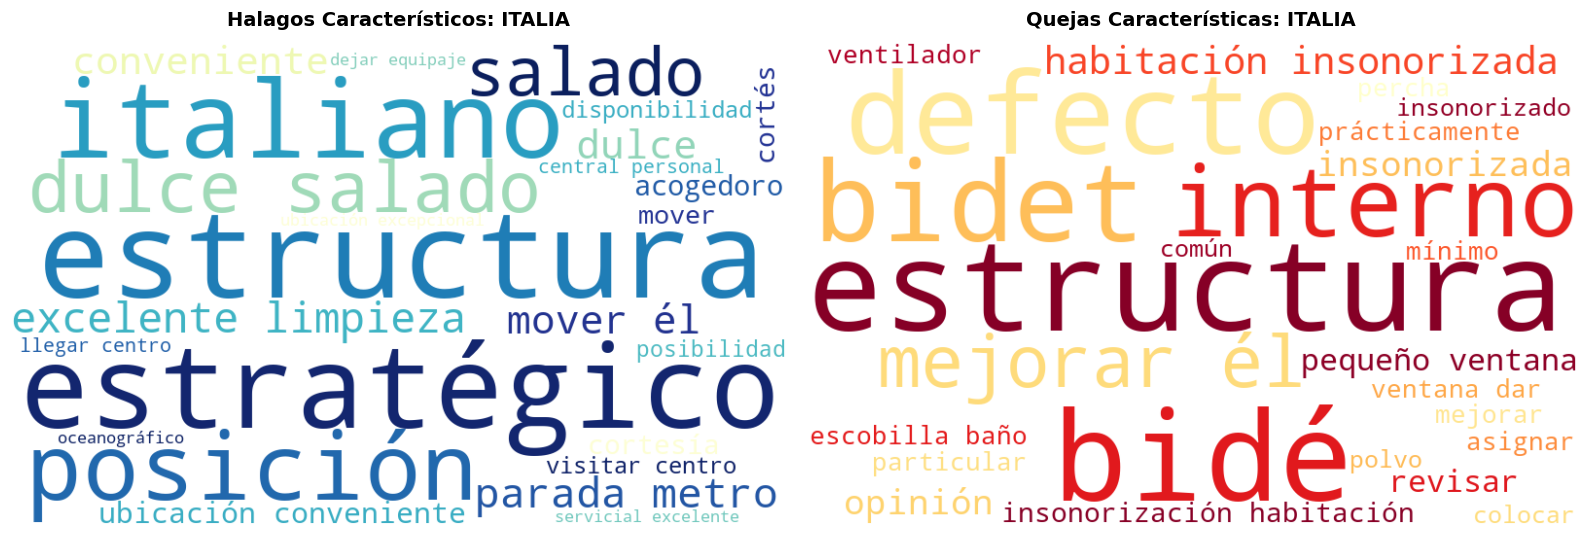

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

def generar_wordclouds_logodds(cuentas_pos, cuentas_neg, pais_target, top_n=30):
    """
    Genera dos WordClouds utilizando los scores de LogOdds como pesos 
    para reflejar la importancia relativa por país.
    """
    logodds_pos = LogOdds_multi(cuentas_pos, pais_target)
    logodds_neg = LogOdds_multi(cuentas_neg, pais_target)
    
    top_pos_words = logodds_pos.columns[-top_n:].tolist()
    top_pos_scores = logodds_pos.iloc[0, -top_n:].tolist()
    dict_pos = dict(zip(top_pos_words, top_pos_scores))
    
    top_neg_words = logodds_neg.columns[-top_n:].tolist()
    top_neg_scores = logodds_neg.iloc[0, -top_n:].tolist()
    dict_neg = dict(zip(top_neg_words, top_neg_scores))
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    wordcloud_pos = WordCloud(
        width=800, height=500,
        background_color='white',
        colormap='YlGnBu', 
        max_words=top_n
    ).generate_from_frequencies(dict_pos) 
    
    axes[0].imshow(wordcloud_pos, interpolation='bilinear')
    axes[0].set_title(f"Halagos Característicos: {pais_target.upper()}", fontsize=14, fontweight='bold', pad=10)
    axes[0].axis('off')
    
    wordcloud_neg = WordCloud(
        width=800, height=500,
        background_color='white',
        colormap='YlOrRd',  
        max_words=top_n
    ).generate_from_frequencies(dict_neg)
    
    axes[1].imshow(wordcloud_neg, interpolation='bilinear')
    axes[1].set_title(f"Quejas Características: {pais_target.upper()}", fontsize=14, fontweight='bold', pad=10)
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()

generar_wordclouds_logodds(cuentas_pos_tot, cuentas_neg_tot, pais_target='italia', top_n=25)

### 2.3. Calificaciones por nacionalidad
Calculamos la media global de cada país junto al total de reseñas.

In [87]:
print("\n--- ANÁLISIS DE EXIGENCIA CUANTITATIVA ---")
analisis_notas = df_proyecto.groupby('nacionalidad').agg(
    nota_media_global=('nota', 'mean'),
    total_reseñas=('nota', 'count')
).round(2).sort_values(by='nota_media_global')

display(analisis_notas)


--- ANÁLISIS DE EXIGENCIA CUANTITATIVA ---


,nota_media_global,total_reseñas
nacionalidad,,
alemania,8.25,3122
españa,8.30,16915
bélgica,8.35,1335
francia,8.38,2684
suiza,8.38,1364
países bajos,8.39,3153
italia,8.64,9377
argentina,8.71,1334
reino unido,8.71,3355


### 2.3. Análisis de intensidad de las quejas para cada nacionalidad

Definimos una función para cuantificar el nivel de enfado expresado en cada reseña. Para ello, definimos una lista con términos específicos de amplificación negativa en español. Se contabiliza cuántas de estas palabras aparecen en cada comentario negativo individual.

In [88]:
# Definimos una lista de amplificadores de queja en español
amplificadores = ['muy', 'bastante', 'demasiado', 'fatal', 'pesimo', 'pésimo', 'malisimo', 'malísimo', 'nunca', 'jamas', 'jamás']

def calcular_intensidad_queja(texto):
    if pd.isna(texto): return 0
    palabras = str(texto).lower().split()
    # Contamos cuántas palabras de la reseña son amplificadores negativos
    coincidencias = sum(1 for p in palabras if p in amplificadores)
    return coincidencias

# Aplicamos a la columna original de negativos
df_proyecto['intensidad_negativa'] = df_proyecto['negativo'].apply(calcular_intensidad_queja)

# Calculamos la media por país
print("--- INTENSIDAD VERBAL DE LA QUEJA POR PAÍS ---")
display(df_proyecto.groupby('nacionalidad')['intensidad_negativa'].mean().round(2))

--- INTENSIDAD VERBAL DE LA QUEJA POR PAÍS ---


nacionalidad
alemania          0.17
argentina         0.12
bélgica           0.13
españa            0.11
estados unidos    0.11
francia           0.14
italia            0.09
países bajos      0.14
reino unido       0.13
suiza             0.15
Name: intensidad_negativa, dtype: float64

Contamos las palabras reales escritas en la sección de comentarios negativos (parece que los que más se quejan son los alemanes).

--- NÚMERO DE PALABRAS EN LA QUEJA ---


,longitud_media_palabras,maxima_longitud_registrada
nacionalidad,,
alemania,28.9,382
reino unido,25.8,354
estados unidos,23.8,265
bélgica,22.5,209
francia,21.2,288
suiza,21.1,316
españa,20.7,329
italia,19.6,331
países bajos,19.2,349


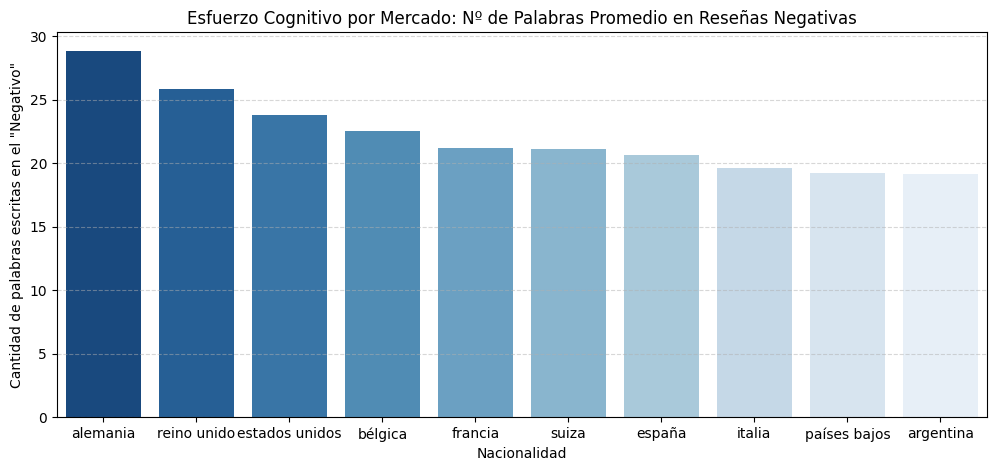

In [92]:
# Calculamos el conteo de palabras reales en la columna original de quejas (negativo)
df_proyecto['longitud_queja'] = df_proyecto['negativo'].apply(lambda x: len(str(x).split()) if pd.notna(x) and str(x).lower() not in ['nada', 'ninguna', ''] else 0)

# Filtramos filas donde realmente existió una queja (longitud > 0) para no desvirtuar la media
df_quejas_reales = df_proyecto[df_proyecto['longitud_queja'] > 0]

# Agrupamos por nacionalidad para extraer la métrica exacta de esfuerzo verbal
analisis_esfuerzo = df_quejas_reales.groupby('nacionalidad').agg(
    longitud_media_palabras=('longitud_queja', 'mean'),
    maxima_longitud_registrada=('longitud_queja', 'max')
).round(1).sort_values(by='longitud_media_palabras', ascending=False)

print("--- NÚMERO DE PALABRAS EN LA QUEJA ---")
display(analisis_esfuerzo)

# Gráfico de barras para la entrega/diapositivas
plt.figure(figsize=(12, 5))
sns.barplot(data=df_quejas_reales, x='nacionalidad', y='longitud_queja', errorbar=None, palette='Blues_r', order=analisis_esfuerzo.index)
plt.title('Esfuerzo Cognitivo por Mercado: Nº de Palabras Promedio en Reseñas Negativas')
plt.xlabel('Nacionalidad')
plt.ylabel('Cantidad de palabras escritas en el "Negativo"')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### 2.4. Nota media según la habitación que se haya escogido

In [ ]:
print("--- NOTA MEDIA SEGÚN EL TIPO DE VIAJERO ---")
analisis_viajero = df_proyecto.groupby('detalles_hab')['nota'].agg(['mean', 'count']).round(2)
display(analisis_viajero)

# Extraemos qué queja domina en cada tipo de cliente (ejemplo con España)
df_es = df_proyecto[df_proyecto['nacionalidad'] == 'españa']
for tipo in df_es['detalles_hab'].dropna().unique()[:3]:
    df_sub = df_es[df_es['detalles_hab'] == tipo]
    print(f"\nTop menciones de quejas para el segmento [{tipo}]:")
    print(df_sub['negativo_clean'].str.split(expand=True).stack().value_counts().head(3))

--- NOTA MEDIA SEGÚN EL TIPO DE VIAJERO ---


,mean,count
detalles_hab,,
2 habitaciones dobles deluxe comunicadas,9.05,86
alojamiento the level supreme,8.97,142
cama en habitación compartida mixta de 4 camas,8.32,398
cama en habitación compartida mixta de 6 camas,8.13,305
cama en habitación compartida mixta de 8 camas,8.33,273
...,...,...
suite junior con vistas al mar,8.21,90
suite junior supreme the level,9.06,62
suite presidencial the level,9.20,5



Top menciones de quejas para el segmento [2 habitaciones dobles deluxe comunicadas]:
piscina      3
funcionar    3
pequeño      2
Name: count, dtype: int64

Top menciones de quejas para el segmento [habitación doble estándar con vistas a la plaza del ayuntamiento]:
pequeño    10
haber       7
más         7
Name: count, dtype: int64

Top menciones de quejas para el segmento [habitación estándar]:
pequeño    36
baño       24
gustar     20
Name: count, dtype: int64


### 2.5. Análisis de calificaciones por bloque geográfico
Clasificamos las nacionalidades en dos grandes bloques geográficos según su distancia y proximidad cultural con el destino: el entorno europeo y el mercado intercontinental de larga distancia. A continuación, aplicamos esta segmentación al conjunto de datos para calcular la nota media de cada bloque, contrastando si el factor de la distancia física influye de manera directa en las expectativas y el nivel de exigencia numérica del turista.

In [ ]:
# Definimos los bloques geográficos basados en tus países
paises_proximidad = ['españa', 'francia', 'italia', 'reino unido', 'países bajos', 'alemania', 'suiza', 'bélgica']
paises_distancia = ['argentina', 'estados unidos']

# Creamos la nueva variable de segmentación cultural
def asignar_bloque(pais):
    if pais in paises_proximidad: return 'Europa (Proximidad)'
    if pais in paises_distancia: return 'Intercontinental (Larga Distancia)'
    return 'Otros'

df_proyecto['bloque_cultural'] = df_proyecto['nacionalidad'].apply(asignar_bloque)

# Comparamos las notas medias para ver el impacto reputacional
print("--- NOTA MEDIA POR BLOQUE GEOGRÁFICO ---")
print(df_proyecto.groupby('bloque_cultural')['nota'].mean().round(2))

# Extraemos el Top de quejas para ver si se rompe la homogeneidad
print("\n--- QUEJAS TOP: EUROPA ---")
df_euro = df_proyecto[df_proyecto['bloque_cultural'] == 'Europa (Proximidad)']
print(df_euro['negativo_clean'].value_counts().head(5))

print("\n--- QUEJAS TOP: INTERCONTINENTAL ---")
df_inter = df_proyecto[df_proyecto['bloque_cultural'] == 'Intercontinental (Larga Distancia)']
print(df_inter['negativo_clean'].value_counts().head(5))

--- NOTA MEDIA POR BLOQUE GEOGRÁFICO ---
bloque_cultural
Europa (Proximidad)                   8.42
Intercontinental (Larga Distancia)    8.81
Name: nota, dtype: float64

--- QUEJAS TOP: EUROPA ---
negativo_clean
                26853
gustar            162
perfecto          161
pequeño            83
baño pequeño       62
Name: count, dtype: int64

--- QUEJAS TOP: INTERCONTINENTAL ---
negativo_clean
            1630
perfecto      14
gustar        13
queja          9
pequeño        9
Name: count, dtype: int64


### 2.6. Tendencia a añadir quejas en la columna de comentarios positivos por nacionalidad

In [24]:
# Buscamos palabras típicamente negativas ('pero', 'malo', 'pequeño', 'viejo', 'ruido') dentro de la columna de POSITIVOS
palabras_criticas = ['pero', 'pequeno', 'pequeño', 'ruido', 'antiguo', 'viejo', 'caro', 'defecto']

df_proyecto['critica_infiltrada'] = df_proyecto['positivo_clean'].fillna("").apply(
    lambda x: 1 if any(p in str(x).lower() for p in palabras_criticas) else 0
)

print("--- PORCENTAJE DE CLIENTES QUE SE QUEJAN INCLUSO EN LA COLUMNA DE POSITIVOS ---")
critica_cultural = df_proyecto.groupby('nacionalidad')['critica_infiltrada'].mean() * 100
display(critica_cultural.sort_values(ascending=False).round(1))

--- PORCENTAJE DE CLIENTES QUE SE QUEJAN INCLUSO EN LA COLUMNA DE POSITIVOS ---


nacionalidad
alemania          6.0
reino unido       5.4
bélgica           4.8
países bajos      4.4
francia           4.1
estados unidos    3.8
suiza             3.6
italia            2.7
argentina         1.9
españa            1.8
Name: critica_infiltrada, dtype: float64

### 2.7. Análisis de especificidad
A continuación realizaremos un análisis de especifidad que aísla el ruido de las quejas masivas. Primero binarizamos el texto libre generando variables categóricas para los seis problemas más recurrentes y construimos. Aplicamos un test estadístico de Chi-cuadrado para modelar las frecuencias teóricas globales y calculamos la matriz de residuos estandarizados.

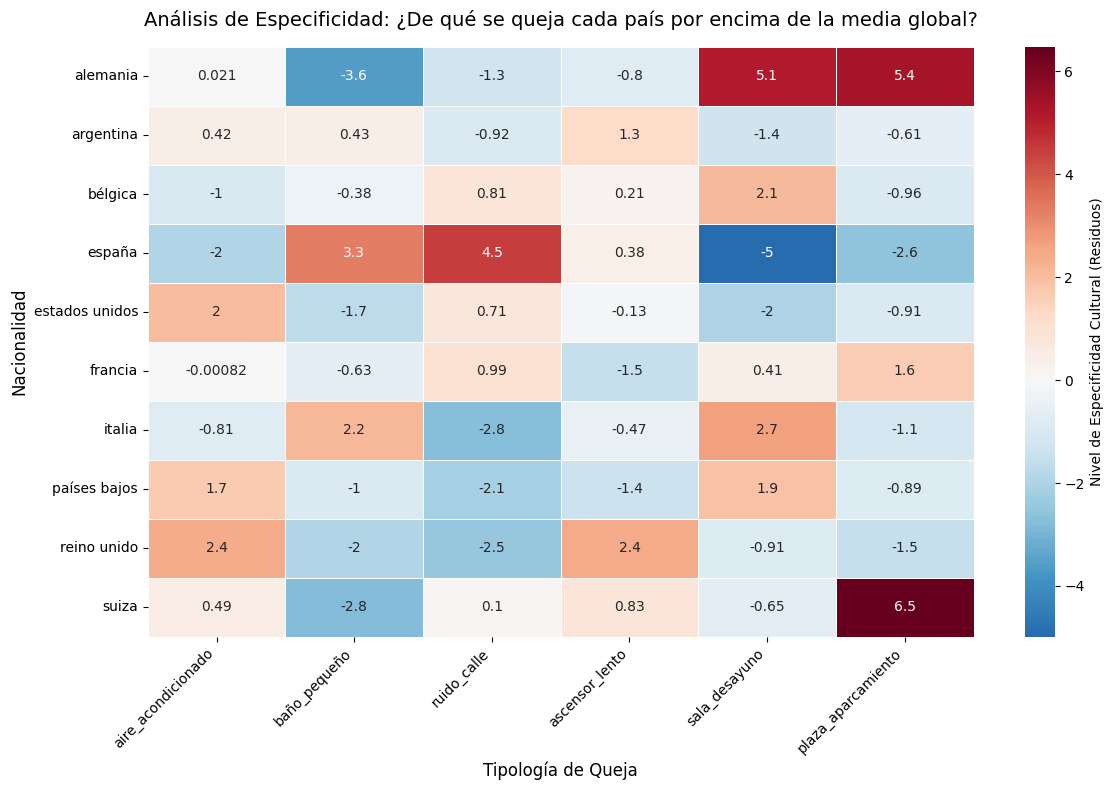

In [94]:
# Creamos las variables dummy de las quejas clave en el dataset general
df_proyecto['aire_acondicionado'] = df_proyecto['negativo_clean'].fillna("").str.contains('aire acondicionado').astype(int)
df_proyecto['baño_pequeño'] = df_proyecto['negativo_clean'].fillna("").str.contains('baño pequeño').astype(int)
df_proyecto['ruido_calle'] = df_proyecto['negativo_clean'].fillna("").str.contains('ruido calle').astype(int)
df_proyecto['ascensor_lento'] = df_proyecto['negativo_clean'].fillna("").str.contains('ascensor lento').astype(int)
df_proyecto['sala_desayuno'] = df_proyecto['negativo_clean'].fillna("").str.contains('sala desayuno').astype(int)
df_proyecto['plaza_aparcamiento'] = df_proyecto['negativo_clean'].fillna("").str.contains('plaza aparcamiento').astype(int)

# Creamos la tabla de contingencia (País vs Quejas) sumando las ocurrencias
lista_quejas = ['aire_acondicionado', 'baño_pequeño', 'ruido_calle', 'ascensor_lento', 'sala_desayuno', 'plaza_aparcamiento']
tabla_contingencia = df_proyecto.groupby('nacionalidad')[lista_quejas].sum()

# Aplicamos el test de Chi-cuadrado para obtener los residuos estandarizados
# Los residuos miden cuánto se aleja la realidad de la media teórica global
chi2, p, dof, esperados = chi2_contingency(tabla_contingencia)
residuos = (tabla_contingencia-esperados)/(esperados ** 0.5)

# Pintamos el mapa de calor de las desviaciones culturales
plt.figure(figsize=(12, 8))
sns.heatmap(
    residuos, 
    annot=True, 
    cmap='RdBu_r', 
    center=0, 
    cbar_kws={'label': 'Nivel de Especificidad Cultural (Residuos)'},
    linewidths=0.5
)

plt.title('Análisis de Especificidad: ¿De qué se queja cada país por encima de la media global?', fontsize=14, pad=15)
plt.xlabel('Tipología de Queja', fontsize=12)
plt.ylabel('Nacionalidad', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Referencias
- https://antonio-velazquez-bustamante.medium.com/comparing-political-speeches-with-python-and-nlp-54cd506e91b9  
- https://acua.qcri.org/blog/log-odds-ratio-going-beyond-simple-term-frequencies-to-characterize-textual-categories/  
- https://www.cambridge.org/core/journals/political-analysis/article/fightin-words-lexical-feature-selection-and-evaluation-for-identifying-the-content-of-political-conflict/81B3703230D21620B81EB6E2266C7A66
- https://www.sciencedirect.com/science/article/pii/S2666957925000059